## TC 5033
### Text Classifier with RNNs

<br>

### Nombres: Freddy Silva, César Cruz, Fernando Guevara, Kailin Wu
### Matrículas: A00828792, A00825747, A00828723, A00830574


#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [4]:
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [5]:
!pip install scipy==1.9.3
!pip install scikit-plot
#you may receive a message of restarting session, this is OK

  Using cached scipy-1.9.3.tar.gz (42.1 MB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... error
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [50 lines of output]
      + meson setup /tmp/pip-install-g3m0x2dt/scipy_3d368730f1ca484c830622aca81790be /tmp/pip-install-g3m0x2dt/scipy_3d368730f1ca484c830622aca81790be/.mesonpy-wbpfs7e_ -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=/tmp/pip-install-g3m0x2dt/scipy_3d368730f1ca484c830622aca81790be/.mesonpy-wbpfs7e_/meson-python-native-file.ini
      The Meson build system
      Version: 1.10.1
      Source dir: /tmp/pip-install-g3m0x2dt/scipy_3d368730f1ca484c830622aca81790be
      Build dir: /tmp/pip-install-g3m0x2dt/scipy_3d368730f1ca484c830622aca81790be/.mesonpy-wbpfs7e_
      Build type: native build
      Projec

In [6]:
!pip install portalocker
!pip install "numpy<2"
#please restar session after this intallation. After restarting go straight to importing the libraries


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Import libraries

In [2]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F

# These libraries are suggested to plot confusion matrix
# you may use others
import scipy
scipy.interp = np.interp
import scikitplot as skplt
import gc

In [3]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Get the train and the test datasets and dataloaders
Prepares the full date pipeline for training a text classifier on the AG_NEWS dataset. It loads and converts the dataset, builds a vocabulary from the training text, splits off a validation set, and defines a collate_batch function that tokenizes, pads and tensorizes each batch.

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

We convert to Map-style so we could use indices and random_split

In [4]:
train_dataset, test_dataset = AG_NEWS()
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

We use *basic_english* for text normalizing. (Lowercasing, punctuation, etc). And create *yield_tokens* to process text word by word.

In [ ]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    """
    Generator thet tokenizes each text entry in the dataset.

    Args:
        data (dataset): Iterable dataset where each item is a tuple.

    Yields:
        list (str): A list of tokens for each text sample.
    """
    for _, text in data:
        yield tokeniser(text)

In [6]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

In [7]:
#test tokens
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


To avoid overfitting, 10% of train data is separated for validation.

In [ ]:
# 90% of training data used for training, 10% for validation
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [ ]:
# Split the training dataset into train and validation subsets
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [ ]:
# Verify split sizes
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


Function *collate_batch* transforms list in tensors.

In [ ]:
# function passed to the DataLoader to process a batch of data as indicated
def collate_batch(batch):
    """
    Processes a raw batch of samples into padded tensors ready for model input.
    
    Args:
        batch (list): List of tuples from the dataset.

    Returns:
        tuple:
            - torch.Tensor (int32): Padded token index matrix of shape (batch_size, max_tokens).
            - torch.Tensor (int32): Label tensor (0-indexed) of shape (batch_size).
    """
    # Get label and text
    y, x = list(zip(*batch))

    # Create list with indices from tokeniser
    x = [vocab(tokeniser(text)) for text in x]
    x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Prepare the labels, by subtracting 1 to get them in the range 0-3
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

In [12]:
labels =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 256

Finally, creating the loaders that will feed the model in batches of 256 news.

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### Let us build our RNN model
This section defines and trains a GRU-based text classifier on the AG_NEWS dataset. The RNN_Model_1 class embeds tokens, processes them through stacked GRU layers, and classifies via a linear head. The train function runs the full training loop with loss backpropagation. The accuracy function evaluated performance, smaple_text previews individual predictions, and plot_confusion_matrix visualizes per-class performance.

In [ ]:
EMBEDDING_SIZE = 300    # Size of the dense vector for each word token
NEURONS = 256           # Number of hidden units in the GRU layer
LAYERS = 2              # Number of stacked GRU layers
NUM_CLASSES = 4         # Number of output classes

In [ ]:
import torch.nn as nn

class RNN_Model_1(nn.Module):
    """
    A text classification model using a GRU-based RNN.

    Architecture:
        1. Embedding layer: Maps token indices to dense vectors.
        2. GRU layer: Processes the sequence and captures temporal dependencies.
        3. Fully connected layer: Maps the last hidden state to class logits.
    
    Args:
        embed_size (int): Dimensionality of the word embedding vectors
        hidden (int): Number of hidden units in the GRU.
        layers (int): Number of stacked GRU layers.
        num_classes (int): Number of output classification categories
    """

    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()
        # Embedding: turns indices into dense vectors
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab), 
                                            embedding_dim=embed_size)

        # Using GRU for speed and memory. 
        # batch_first=True tells us that it will be [Batch, Seq_Len, Features]
        self.rnn = nn.GRU(input_size=embed_size, 
                          hidden_size=hidden, 
                          num_layers=layers, 
                          batch_first=True)

        # Linear classifier mapping hidden layer neurons.
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, x):
        """
        Defines the forward pass of the model.

        Args:
            x (torch.Tensor): Input tensor of token indices, shape [Batch, Seq_Len].

        Returns:
            torch.Tensor: Class logits of shape [Batch, num_classes].
        """

        # Convert token indices to dense embedding vectors
        embedded = self.embedding_layer(x)

        # Pass embedding through the GRU
        rnn_out, hidden = self.rnn(embedded)
        
        # We only take the last time step
        # rnn_out[:, -1, :] takes last sequence vector 
        last_time_step = rnn_out[:, -1, :]
        
        # Final clasification
        logits = self.fc(last_time_step)
        
        return logits

# Instantiate the model with the defined hyperparameters
model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)

In [ ]:
def accuracy(model, loader):
    """
    Computes the classification accuracy of the model on a given dataset.

    Args:
        model (nn.Module): The trained Pytorch model.
        loader (DataLoader): DataLoader providing batches of (x, y) pairs.
    
    Returns:
        float: Accuracy score as value between 0 and 1.
    """
    
    # Set model to evaluation mode
    model.eval()
    
    correct = 0
    total = 0
    
    # Disable gradient computation for efficiency
    with torch.no_grad():
        for x, y in loader:
            # Ensuring data lies within the same device as the model. (CPU o GPU)
            x = x.to(device=next(model.parameters()).device)
            y = y.to(device=next(model.parameters()).device)
            
            # Predictions (logits)
            logits = model(x)
            
            # 4. Encontramos el índice de la clase con el valor más alto (predicción)
            # dim=1 because we look for the max in class columns.
            _, preds = torch.max(logits, dim=1)
            
            correct += (preds == y).sum().item()
            total += y.size(0)
    
    return correct / total

In [ ]:
def train(model, optimiser, epochs=100):
    """
    Trains the model using CrossEntropy loss and evaluates after each epoch.

    Args:
        model (nn.Module): The RNN model to train.
        optimiser (torch.optim.Optimizer): Optimizer for updating model weights.
        epochs (int, optional): Number of full passes over the training data. Default 100.

    Returns:
        None: Prints loss and accuracy metrics after each epoch.
    """

    # 1. Define loss function
    # CrossEntropy includes Softmax.
    loss_function = nn.CrossEntropyLoss()
    
    # Use GPU if available
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    print(f"Training with: {device}")

    for epoch in range(epochs):
        model.train() # Training mode
        total_loss = 0
        
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device).long()
            
            # Previous gradients cleanising
            optimiser.zero_grad()
            
            # B. Forward
            logits = model(x)
            loss = loss_function(logits, y)
            
            # C. Backward
            loss.backward()
            optimiser.step()
            
            total_loss += loss.item()
        
        # 2. Final evaluation
        train_acc = accuracy(model, train_loader)
        val_acc = accuracy(model, val_loader)
        
        print(f'Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | '
              f'Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}')

In [ ]:
# Between 10 to 20 is enought to not overfit.
epochs = 10 

lr = 0.001 

rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)

optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)

train(rnn_model, optimiser, epochs=epochs)

Entrenando en: cpu
Epoch 1/10 | Loss: 0.5423 | Train Acc: 0.9177 | Val Acc: 0.8945
Epoch 2/10 | Loss: 0.2272 | Train Acc: 0.9512 | Val Acc: 0.9133
Epoch 3/10 | Loss: 0.1535 | Train Acc: 0.9699 | Val Acc: 0.9150
Epoch 4/10 | Loss: 0.1000 | Train Acc: 0.9792 | Val Acc: 0.9122
Epoch 5/10 | Loss: 0.0632 | Train Acc: 0.9882 | Val Acc: 0.9119
Epoch 6/10 | Loss: 0.0439 | Train Acc: 0.9934 | Val Acc: 0.9125
Epoch 7/10 | Loss: 0.0285 | Train Acc: 0.9954 | Val Acc: 0.9111
Epoch 8/10 | Loss: 0.0211 | Train Acc: 0.9949 | Val Acc: 0.9087
Epoch 9/10 | Loss: 0.0193 | Train Acc: 0.9957 | Val Acc: 0.9096
Epoch 10/10 | Loss: 0.0164 | Train Acc: 0.9967 | Val Acc: 0.9075


In [ ]:
# Evaluate final accuracy
print(f'{accuracy(rnn_model, test_loader):.4f}')

0.9079


In [ ]:
def sample_text(model, loader):
    """
    Displays the predicted vs. real label alongside the decoded text for the first 5
    samples in a single batch.

    Args:
        model (nn.Module): The trained RNN model.
        loader (DataLoader): DataLoader to sample a batch from.

    Returns:
        None: Prints a formatted table of predictions vs. real.
    """
    
    # Set to evaluation mode
    model.eval()
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    
    # Inverse map for vocab (ID -> Word)
    # This allows us to reconstruct the phrase.
    itos = vocab.get_itos()
    
    # Taking just one batch.
    x, y = next(iter(loader))
    
    with torch.no_grad():
        x, y = x.to(device), y.to(device)
        logits = model(x)
        _, preds = torch.max(logits, dim=1)
    
    # First five examples.
    print(f"{'Prediction':<15} | {'REAL':<15} | {'TEXT'}")
    print("-" * 80)
    
    # Display results for the first 5 samples
    for i in range(5):
        text_indices = x[i].tolist()
        tokens = [itos[idx] for idx in text_indices if idx != 0] # 0 is usually the padding
        sentence = " ".join(tokens[:10]) + "..." 
        
        pred_label = labels[preds[i].item()]
        true_label = labels[y[i].item()]
        
        print(f"{pred_label:<15} | {true_label:<15} | {sentence}")

In [26]:
sample_text(rnn_model, test_loader)

Prediction      | REAL            | TEXT
--------------------------------------------------------------------------------
World           | World           | israelis kill five in gaza strip israeli troops killed five...
Sports          | World           | cricket dubai global academy the international cricket council are to...
Sports          | Sports          | broken thumb sidelines payton results of x-rays on gary payton...
World           | World           | earthquake rocks indonesia ' s bali , one jakarta (...
World           | World           | darfur warring parties to meet in nigeria for peace talks...


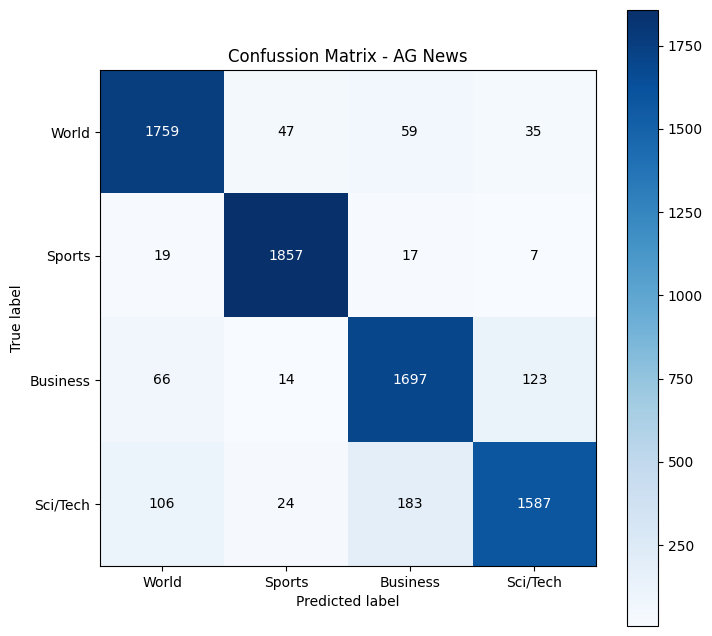

In [ ]:
import matplotlib.pyplot as plt
import scikitplot as skplot

def plot_confusion_matrix(model, loader):
    """
    Generates and displays a confusion matrix for the model's predictions
    on the provided dataset.

    Args:
        model (nn.Module): The trained RNN model.
        loader (DataLoader): DataLoader providing the evaluation dataset.

    Returns:
        None: Renders a labeled confusion matrix plot.
    """

    model.eval()    # Evaluation mode
    y_true = []     # True labels
    y_pred = []     # Predicted lables
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            # Save real labels.
            y_true.extend(y.numpy())
            
            # Get model predictions
            logits = model(x)
            _, preds = torch.max(logits, dim=1)
            y_pred.extend(preds.cpu().numpy())
    
    skplot.metrics.plot_confusion_matrix(y_true, y_pred, figsize=(8,8), title="Confussion Matrix - AG News")
    
    # Adjusting names
    tick_marks = range(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)
    plt.show()

# Plot confusion matrix on the test set
plot_confusion_matrix(rnn_model, test_loader)